In [ ]:
# Install required libraries
!pip install -q openpyxl scikit-learn joblib matplotlib seaborn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
uploaded = files.upload()

Saving expense_training_dataset_3_months_6000.xlsx to expense_training_dataset_3_months_6000.xlsx


In [ ]:
# Get uploaded filename
file_name = list(uploaded.keys())[0]

# Read Excel dataset
df = pd.read_excel(file_name)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (6000, 7)


,transaction_id,transaction_date,source,amount,payment_method,expense_mode,category
0,1702,2026-05-01,bus ticket to university,6507.49,Debit Card,Personal,Transport
1,1516,2026-05-01,KFC lunch for family,3529.49,Credit Card,Personal,Food
2,5567,2026-05-01,train ticket to university,12105.54,Mobile Payment,Personal,Transport
3,1507,2026-05-01,internet bill,1933.76,Credit Card,Personal,Bills
4,3614,2026-05-01,trip expenses,87387.63,Debit Card,Personal,Travel


In [ ]:
print("Column names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nCategory distribution:")
print(df["category"].value_counts())

Column names:
['transaction_id', 'transaction_date', 'source', 'amount', 'payment_method', 'expense_mode', 'category']

Missing values:
transaction_id      0
transaction_date    0
source              0
amount              0
payment_method      0
expense_mode        0
category            0
dtype: int64

Duplicate rows:
0

Category distribution:
category
Food             1200
Transport         825
Shopping          816
Bills             792
Entertainment     655
Education         580
Travel            570
Health            562
Name: count, dtype: int64


In [ ]:
# Remove rows with missing source or category
df = df.dropna(subset=["source", "category"])

# Convert source and category to string
df["source"] = df["source"].astype(str).str.strip()
df["category"] = df["category"].astype(str).str.strip()

# Remove empty source values
df = df[df["source"] != ""]

print("Dataset after cleaning:", df.shape)

Dataset after cleaning: (6000, 7)


In [ ]:
# Input feature
X = df["source"]

# Target label
y = df["category"]

print("Example Input:")
print(X.iloc[0])

print("\nExample Target:")
print(y.iloc[0])

Example Input:
bus ticket to university

Example Target:
Transport


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4800
Testing samples: 1200


In [ ]:
svm_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=1
        )
    ),
    (
        "classifier",
        LinearSVC()
    )
])

In [ ]:
print("Training Linear SVM model...")

svm_model.fit(X_train, y_train)

print("Training completed successfully! ✅")

Training Linear SVM model...
Training completed successfully! ✅


In [ ]:
# Predict categories for test data
y_pred_svm = svm_model.predict(X_test)

print("Prediction completed!")

Prediction completed!


In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

precision = precision_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)

print("Linear SVM + TF-IDF Results")
print("--------------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Linear SVM + TF-IDF Results
--------------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [ ]:
print(
    classification_report(
        y_test,
        y_pred_svm,
        zero_division=0
    )
)

               precision    recall  f1-score   support

        Bills       1.00      1.00      1.00       158
    Education       1.00      1.00      1.00       116
Entertainment       1.00      1.00      1.00       131
         Food       1.00      1.00      1.00       240
       Health       1.00      1.00      1.00       113
     Shopping       1.00      1.00      1.00       163
    Transport       1.00      1.00      1.00       165
       Travel       1.00      1.00      1.00       114

     accuracy                           1.00      1200
    macro avg       1.00      1.00      1.00      1200
 weighted avg       1.00      1.00      1.00      1200



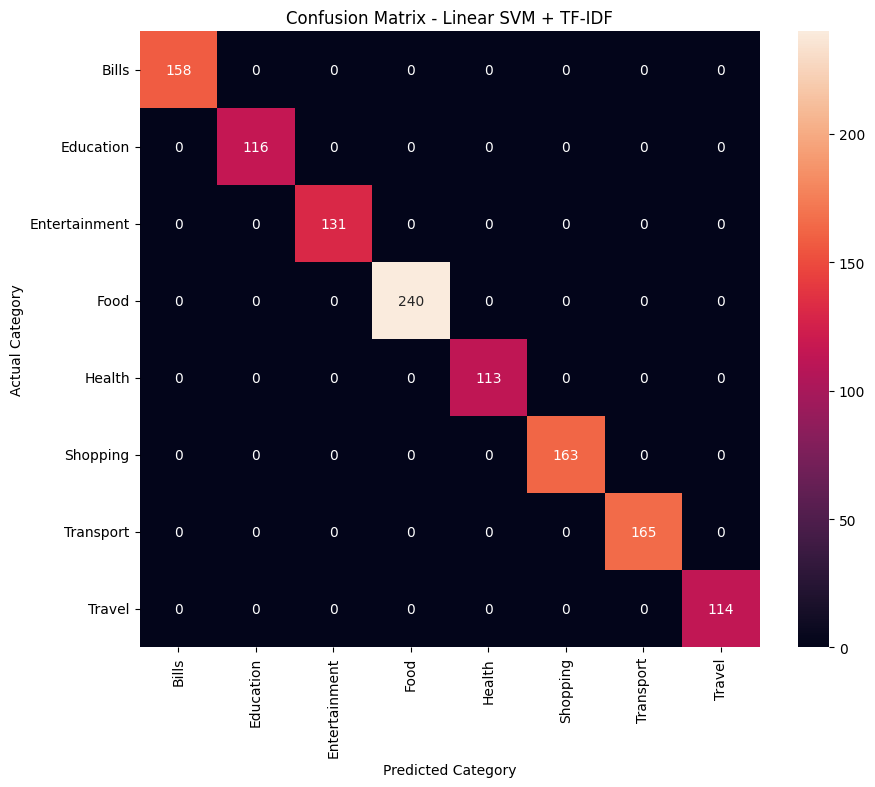

In [ ]:
# Get all category labels
labels = sorted(y.unique())

# Generate confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=labels
)

# Plot confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Confusion Matrix - Linear SVM + TF-IDF")

plt.show()

In [ ]:
new_expenses = [
    "KFC lunch with friends",
    "Uber ride to university",
    "Electricity bill payment",
    "Bought a new pair of shoes",
    "University programming textbook",
    "Bought medicine from pharmacy",
    "Netflix monthly subscription",
    "Hotel booking for holiday"
]

predictions = svm_model.predict(
    new_expenses
)

for expense, prediction in zip(
    new_expenses,
    predictions
):
    print(
        f"{expense}  -->  {prediction}"
    )

KFC lunch with friends  -->  Food
Uber ride to university  -->  Transport
Electricity bill payment  -->  Bills
Bought a new pair of shoes  -->  Shopping
University programming textbook  -->  Education
Bought medicine from pharmacy  -->  Health
Netflix monthly subscription  -->  Entertainment
Hotel booking for holiday  -->  Travel


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_nb,
        accuracy_svm
    ],
    "Precision": [
        precision_logistic,
        precision_nb,
        precision_svm
    ],
    "Recall": [
        recall_logistic,
        recall_nb,
        recall_svm
    ],
    "F1 Score": [
        f1_logistic,
        f1_nb,
        f1_svm
    ]
})

print(results)

NameError: name 'accuracy_logistic' is not defined